# 📦 Batch Processing Datasets: Real-World RAG Evaluation

**Goal:** Learn how to evaluate entire datasets efficiently for production RAG systems.

In this tutorial, you'll learn:
1. How to structure test datasets for batch evaluation
2. Applying multiple metrics simultaneously
3. Using `evaluate_batch()` for efficient processing
4. Converting results to DataFrames for analysis
5. Calculating aggregate quality metrics
6. Identifying problematic outputs automatically

---

## 🎯 Real-World Scenario

You're building a **RAG-powered customer support chatbot** and need to:
- Evaluate 10+ test cases covering different scenarios
- Check both **Groundedness** (facts from docs) and **Hallucination** (invented info)
- Generate a quality report for stakeholders
- Flag specific responses that need human review

Let's build this pipeline! 🚀

---

## 📦 Setup

In [ ]:
# API Key Setup
import os

# Using Groq for fast, cost-effective evaluation
GROQ_API_KEY = "gsk_YOUR_API_KEY_HERE"

# Or from environment
# GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [2]:
# Imports
from langchain_groq import ChatGroq

from llm_jury.core.evaluator import JuryEvaluator
from llm_jury.judges.llm_judge import LLMJudge
from llm_jury.metrics.predefined import GroundednessMetric, HallucinationMetric
from llm_jury.strategies.consensus import MajorityVoting

import pandas as pd
import numpy as np
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for better DataFrame viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.width', None)

print("✅ All imports successful!")

✅ All imports successful!


## Setup Evaluation Jury

For batch processing, we'll use 3 judges for a good balance of quality and speed.

In [3]:
print("🏗️ Initializing Jury...\n")

# Create 3 diverse judges
judge_1 = LLMJudge(
    model=ChatGroq(model_name="llama-3.3-70b-versatile", temperature=0.0, api_key=GROQ_API_KEY),
    name="Llama-3.3-70B"
)

judge_2 = LLMJudge(
    model=ChatGroq(model_name="llama-3.1-8b-instant", temperature=0.0, api_key=GROQ_API_KEY),
    name="Llama-3.1-8B"
)

judge_3 = LLMJudge(
    model=ChatGroq(model_name="openai/gpt-oss-120b", temperature=0.0, api_key=GROQ_API_KEY),
    name="GPT-oss-120B"
)

# Create the jury
jury = JuryEvaluator(
    judges=[judge_1, judge_2, judge_3],
    strategy=MajorityVoting()
)

print(f"✅ Jury initialized with {len(jury.judges)} judges")
for judge in jury.judges:
    print(f"   • {judge.name}")

🏗️ Initializing Jury...

✅ Jury initialized with 3 judges
   • Llama-3.3-70B
   • Llama-3.1-8B
   • GPT-oss-120B


## Define Test Dataset

We'll create a realistic test dataset covering various scenarios in our customer support RAG system:
- ✅ Good responses (well-grounded)
- ⚠️ Partial hallucinations (mix of facts and inventions)
- ❌ Clear hallucinations (completely fabricated)
- 🎯 Edge cases (technical, policy, pricing)

In [4]:
# Simulating retrieved knowledge base documents and RAG outputs
test_dataset = {
    "case_001_return_policy": {
        "source_text": """Our return policy allows returns within 30 days of purchase. 
        Items must be unused and in original packaging. Refunds are processed within 5-7 business days. 
        Shipping costs are non-refundable unless the item was defective.""",
        "output": """You can return items within 30 days if they're unused and in original packaging. 
        Refunds take 5-7 business days. Shipping costs aren't refunded unless the item was defective.""",
        "category": "policy"
    },
    
    "case_002_shipping_time": {
        "source_text": """Standard shipping takes 5-7 business days. Express shipping delivers in 2-3 business days. 
        Orders are processed within 24 hours on business days.""",
        "output": """We offer same-day delivery in most areas, with standard shipping taking 3-5 days. 
        All orders ship within 12 hours of placement.""",
        "category": "shipping"
    },
    
    "case_003_pricing": {
        "source_text": """The Pro plan costs $49/month and includes 10 user seats. 
        The Enterprise plan costs $199/month with unlimited seats. 
        Annual billing offers a 20% discount.""",
        "output": """The Pro plan is $49/month for 10 users. Enterprise is $199/month with unlimited users. 
        You save 20% by paying annually.""",
        "category": "pricing"
    },
    
    "case_004_warranty": {
        "source_text": """All products come with a 1-year manufacturer warranty covering defects. 
        Extended warranties are available for purchase at checkout.""",
        "output": """Products have a 2-year warranty covering all damages including accidental breakage. 
        Extended warranties are included free with all purchases over $100.""",
        "category": "policy"
    },
    
    "case_005_payment_methods": {
        "source_text": """We accept Visa, Mastercard, American Express, and PayPal. 
        Payment is processed securely through Stripe.""",
        "output": """We accept all major credit cards (Visa, Mastercard, Amex) and PayPal. 
        Payments are securely processed via Stripe.""",
        "category": "payment"
    },
    
    "case_006_customer_support": {
        "source_text": """Customer support is available Monday-Friday 9 AM to 6 PM EST via chat, email, or phone. 
        Average response time is 2 hours for email and instant for chat.""",
        "output": """Our 24/7 customer support team is available through chat, email, phone, and social media. 
        We guarantee a response within 30 minutes on all channels.""",
        "category": "support"
    },
    
    "case_007_api_limits": {
        "source_text": """Free tier: 1000 API calls/month. Pro tier: 50,000 calls/month. 
        Enterprise: unlimited calls. Rate limit is 100 requests/minute for all tiers.""",
        "output": """Free accounts get 1000 API calls monthly. Pro users get 50,000 calls. 
        Enterprise has unlimited calls. All tiers have a 100 requests/minute rate limit.""",
        "category": "technical"
    },
    
    "case_008_data_privacy": {
        "source_text": """We are GDPR and CCPA compliant. User data is encrypted at rest and in transit. 
        We do not sell user data to third parties. Data retention is 90 days after account deletion.""",
        "output": """Your data is protected under GDPR and CCPA. We use encryption and never sell your data. 
        After deleting your account, data is removed within 90 days.""",
        "category": "privacy"
    },
    
    "case_009_integration": {
        "source_text": """Our platform integrates with Slack, Microsoft Teams, and Zapier. 
        Custom integrations are available via REST API and webhooks.""",
        "output": """We integrate with Slack, Teams, Zapier, Salesforce, and HubSpot out of the box. 
        You can also build custom integrations using our GraphQL API and real-time WebSocket connections.""",
        "category": "technical"
    },
    
    "case_010_mobile_app": {
        "source_text": """Our mobile app is available on iOS (version 14+) and Android (version 10+). 
        Features include offline mode, push notifications, and biometric login.""",
        "output": """Download our app on iOS 14+ or Android 10+. 
        It supports offline access, push notifications, and biometric authentication.""",
        "category": "technical"
    }
}

print(f"Test dataset created with {len(test_dataset)} cases")
print(f"\nCategories: {set(item['category'] for item in test_dataset.values())}")

Test dataset created with 10 cases

Categories: {'privacy', 'technical', 'support', 'payment', 'pricing', 'shipping', 'policy'}


## Define Evaluation Metrics

We'll evaluate each response against TWO metrics:
1. **Groundedness**: Is the answer supported by the retrieved documents?
2. **Hallucination**: Does the answer contain fabricated information?

In [5]:
# Create metrics
groundedness_metric = GroundednessMetric()
hallucination_metric = HallucinationMetric()

metrics = [groundedness_metric, hallucination_metric]

print("Evaluation Metrics:")
for metric in metrics:
    print(f"   • {metric.name}: {metric.description}")
    print(f"     Scale: {metric.scale_min} to {metric.scale_max}")
    print()

Evaluation Metrics:
   • Groundedness: Measures if the answer is derived solely from the source context.
     Scale: 1.0 to 5.0

   • Hallucination: Measures the presence of fabricated or logically inconsistent information.
     Scale: 0.0 to 1.0



## Run Batch Evaluation

This is where the magic happens! The `evaluate_batch()` method will:
- Process all 10 test cases
- Apply both metrics to each case
- Execute judge evaluations in parallel
- Return comprehensive results

**Note:** This will take 30-60 seconds depending on API speed.

In [6]:
print(" Starting batch evaluation...")
print(f"   Cases: {len(test_dataset)}")
print(f"   Metrics: {len(metrics)}")
print(f"   Judges: {len(jury.judges)}")
print(f"   Total evaluations: {len(test_dataset)} × {len(metrics)} = {len(test_dataset) * len(metrics)}")
print(f"\nThis may take 30-60 seconds...\n")

# Run batch evaluation
batch_result = jury.evaluate_batch(
    inputs=test_dataset,
    metrics=metrics
)

print(" Batch evaluation complete!")
print(f"\n Generated {len(batch_result.results)} evaluation results")

 Starting batch evaluation...
   Cases: 10
   Metrics: 2
   Judges: 3
   Total evaluations: 10 × 2 = 20

This may take 30-60 seconds...

 Batch evaluation complete!

 Generated 20 evaluation results


## Convert Results to DataFrame

Let's transform the results into a structured DataFrame for easy analysis.

In [7]:
# Extract data from batch results
results_data = []

for result_key, eval_result in batch_result.results.items():
    # Parse the key: "case_001_return_policy_Groundedness"
    parts = result_key.rsplit('_', 1)
    case_id = parts[0]
    metric_name = parts[1]
    
    # Get category from original dataset
    category = test_dataset[case_id].get('category', 'unknown')
    
    results_data.append({
        'Case ID': case_id,
        'Category': category,
        'Metric': metric_name,
        'Score': eval_result.final_score,
        'Valid': eval_result.is_valid,
        'Confidence': eval_result.confidence,
        'Word Count': eval_result.manifest.features.get('word_count', 0),
        'Complexity': eval_result.manifest.features.get('flesch_reading_ease', 0)
    })

# Create DataFrame
df_results = pd.DataFrame(results_data)

print("\n BATCH EVALUATION RESULTS")
print("="*100)
display(df_results)


 BATCH EVALUATION RESULTS


,Case ID,Category,Metric,Score,Valid,Confidence,Word Count,Complexity
0,case_001_return_policy,policy,Groundedness,5.0,True,1.0000,31,54.44
1,case_001_return_policy,policy,Hallucination,0.0,False,1.0000,31,54.44
2,case_002_shipping_time,shipping,Groundedness,1.0,False,1.0000,23,70.10
3,case_002_shipping_time,shipping,Hallucination,1.0,True,1.0000,23,70.10
4,case_003_pricing,pricing,Groundedness,4.0,True,0.6667,22,80.18
5,case_003_pricing,pricing,Hallucination,0.0,False,1.0000,22,80.18
6,case_004_warranty,policy,Groundedness,1.0,False,1.0000,22,30.32
7,case_004_warranty,policy,Hallucination,1.0,True,1.0000,22,30.32
8,case_005_payment_methods,payment,Groundedness,4.0,True,0.6667,17,48.91
9,case_005_payment_methods,payment,Hallucination,0.0,False,1.0000,17,48.91


## Pivot Table: Scores by Case and Metric

Let's create a more readable view with cases as rows and metrics as columns.

In [8]:
# Create pivot table for scores
pivot_scores = df_results.pivot_table(
    index=['Case ID', 'Category'],
    columns='Metric',
    values='Score',
    aggfunc='first'
)

# Create pivot table for validity
pivot_valid = df_results.pivot_table(
    index=['Case ID', 'Category'],
    columns='Metric',
    values='Valid',
    aggfunc='first'
)

print("\nSCORES BY CASE AND METRIC")
print("="*100)
display(pivot_scores.style.background_gradient(cmap='RdYlGn', vmin=0, vmax=5))

print("\nVALIDITY BY CASE AND METRIC")
print("="*100)
display(pivot_valid)


SCORES BY CASE AND METRIC


,Metric,Groundedness,Hallucination
Case ID,Category,,
case_001_return_policy,policy,5.000000,0.000000
case_002_shipping_time,shipping,1.000000,1.000000
case_003_pricing,pricing,4.000000,0.000000
case_004_warranty,policy,1.000000,1.000000
case_005_payment_methods,payment,4.000000,0.000000
case_006_customer_support,support,1.000000,1.000000
case_007_api_limits,technical,5.000000,0.000000
case_008_data_privacy,privacy,4.000000,0.000000
case_009_integration,technical,2.000000,1.000000



VALIDITY BY CASE AND METRIC


,Metric,Groundedness,Hallucination
Case ID,Category,,
case_001_return_policy,policy,True,False
case_002_shipping_time,shipping,False,True
case_003_pricing,pricing,True,False
case_004_warranty,policy,False,True
case_005_payment_methods,payment,True,False
case_006_customer_support,support,False,True
case_007_api_limits,technical,True,False
case_008_data_privacy,privacy,True,False
case_009_integration,technical,False,True


## Calculate Overall Quality Metrics

Let's compute aggregate statistics to understand the overall performance.

In [9]:
# Overall quality from built-in method
overall_quality = batch_result.overall_quality()

# Calculate additional statistics
groundedness_scores = df_results[df_results['Metric'] == 'Groundedness']['Score']
hallucination_scores = df_results[df_results['Metric'] == 'Hallucination']['Score']

# Validity rates
total_evals = len(df_results)
valid_evals = df_results['Valid'].sum()
validity_rate = (valid_evals / total_evals) * 100

# Confidence statistics
avg_confidence = df_results['Confidence'].mean()
low_confidence_count = (df_results['Confidence'] < 0.6).sum()

print("\n OVERALL QUALITY REPORT")
print("="*70)
print(f"\n Overall Quality Score: {overall_quality:.2f}/5")
print(f"\n Metric Breakdown:")
print(f"   Groundedness:")
print(f"      Mean Score: {groundedness_scores.mean():.2f}/5")
print(f"      Median Score: {groundedness_scores.median():.2f}/5")
print(f"      Std Dev: {groundedness_scores.std():.2f}")
print(f"\n   Hallucination:")
print(f"      Mean Score: {hallucination_scores.mean():.2f}/1")
print(f"      Median Score: {hallucination_scores.median():.2f}/1")
print(f"      Std Dev: {hallucination_scores.std():.2f}")
print(f"\n Validity Rate: {validity_rate:.1f}% ({valid_evals}/{total_evals} passed)")
print(f"\n Confidence Metrics:")
print(f"   Average Confidence: {avg_confidence:.2%}")
print(f"   Low Confidence Cases (<60%): {low_confidence_count}")
print("="*70)


 OVERALL QUALITY REPORT

 Overall Quality Score: 1.75/5

 Metric Breakdown:
   Groundedness:
      Mean Score: 3.10/5
      Median Score: 4.00/5
      Std Dev: 1.66

   Hallucination:
      Mean Score: 0.40/1
      Median Score: 0.00/1
      Std Dev: 0.52

 Validity Rate: 50.0% (10/20 passed)

 Confidence Metrics:
   Average Confidence: 91.67%
   Low Confidence Cases (<60%): 0


## Identify Problematic Cases

Let's automatically flag cases that need human review based on:
- Low scores
- Failed validity checks
- Low confidence

In [10]:
# Define thresholds for flagging
SCORE_THRESHOLD = 3.0  # Below this is concerning
CONFIDENCE_THRESHOLD = 0.6  # Below this needs review

# Flag problematic cases
problematic = df_results[
    (~df_results['Valid']) | 
    (df_results['Score'] < SCORE_THRESHOLD) | 
    (df_results['Confidence'] < CONFIDENCE_THRESHOLD)
].copy()

# Add reason for flagging
def flag_reason(row):
    reasons = []
    if not row['Valid']:
        reasons.append('Failed validity')
    if row['Score'] < SCORE_THRESHOLD:
        reasons.append(f'Low score ({row["Score"]:.1f})')
    if row['Confidence'] < CONFIDENCE_THRESHOLD:
        reasons.append(f'Low confidence ({row["Confidence"]:.0%})')
    return ', '.join(reasons)

problematic['Flag Reason'] = problematic.apply(flag_reason, axis=1)

print("\n CASES FLAGGED FOR REVIEW")
print("="*100)
if len(problematic) > 0:
    display(problematic[['Case ID', 'Category', 'Metric', 'Score', 'Confidence', 'Flag Reason']])
    print(f"\n  {len(problematic)} evaluations flagged out of {len(df_results)} total")
else:
    print(" No cases flagged - all evaluations passed thresholds!")


 CASES FLAGGED FOR REVIEW


,Case ID,Category,Metric,Score,Confidence,Flag Reason
1,case_001_return_policy,policy,Hallucination,0.0,1.0000,"Failed validity, Low score (0.0)"
2,case_002_shipping_time,shipping,Groundedness,1.0,1.0000,"Failed validity, Low score (1.0)"
3,case_002_shipping_time,shipping,Hallucination,1.0,1.0000,Low score (1.0)
5,case_003_pricing,pricing,Hallucination,0.0,1.0000,"Failed validity, Low score (0.0)"
6,case_004_warranty,policy,Groundedness,1.0,1.0000,"Failed validity, Low score (1.0)"
7,case_004_warranty,policy,Hallucination,1.0,1.0000,Low score (1.0)
9,case_005_payment_methods,payment,Hallucination,0.0,1.0000,"Failed validity, Low score (0.0)"
10,case_006_customer_support,support,Groundedness,1.0,1.0000,"Failed validity, Low score (1.0)"
11,case_006_customer_support,support,Hallucination,1.0,1.0000,Low score (1.0)
13,case_007_api_limits,technical,Hallucination,0.0,1.0000,"Failed validity, Low score (0.0)"



  14 evaluations flagged out of 20 total


## Category-Level Analysis

Let's see how different categories (policy, technical, etc.) perform.

In [11]:
# Group by category and metric
category_stats = df_results.groupby(['Category', 'Metric']).agg({
    'Score': ['mean', 'std', 'min', 'max'],
    'Valid': 'mean',
    'Confidence': 'mean'
}).round(2)

print("\n PERFORMANCE BY CATEGORY")
print("="*100)
display(category_stats)

# Find best and worst performing categories
category_avg = df_results.groupby('Category')['Score'].mean().sort_values(ascending=False)

print(f"\n Best Performing Category: {category_avg.index[0]} (avg score: {category_avg.iloc[0]:.2f})")
print(f"  Worst Performing Category: {category_avg.index[-1]} (avg score: {category_avg.iloc[-1]:.2f})")


 PERFORMANCE BY CATEGORY


Score                 Valid Confidence
                         mean   std  min  max  mean       mean
Category  Metric                                              
payment   Groundedness   4.00   NaN  4.0  4.0  1.00       0.67
          Hallucination  0.00   NaN  0.0  0.0  0.00       1.00
policy    Groundedness   3.00  2.83  1.0  5.0  0.50       1.00
          Hallucination  0.50  0.71  0.0  1.0  0.50       1.00
pricing   Groundedness   4.00   NaN  4.0  4.0  1.00       0.67
          Hallucination  0.00   NaN  0.0  0.0  0.00       1.00
privacy   Groundedness   4.00   NaN  4.0  4.0  1.00       0.67
          Hallucination  0.00   NaN  0.0  0.0  0.00       1.00
shipping  Groundedness   1.00   NaN  1.0  1.0  0.00       1.00
          Hallucination  1.00   NaN  1.0  1.0  1.00       1.00
support   Groundedness   1.00   NaN  1.0  1.0  0.00       1.00
          Hallucination  1.00   NaN  1.0  1.0  1.00       1.00
technical Groundedness   3.67  1.53  2.0  5.0  0.67       0.89
          Hallucination  0.33  0.58  0.0  1.0  0.33       0.89


 Best Performing Category: payment (avg score: 2.00)
  Worst Performing Category: support (avg score: 1.00)


## Visualization: Score Distribution

Let's create visualizations to better understand the results.

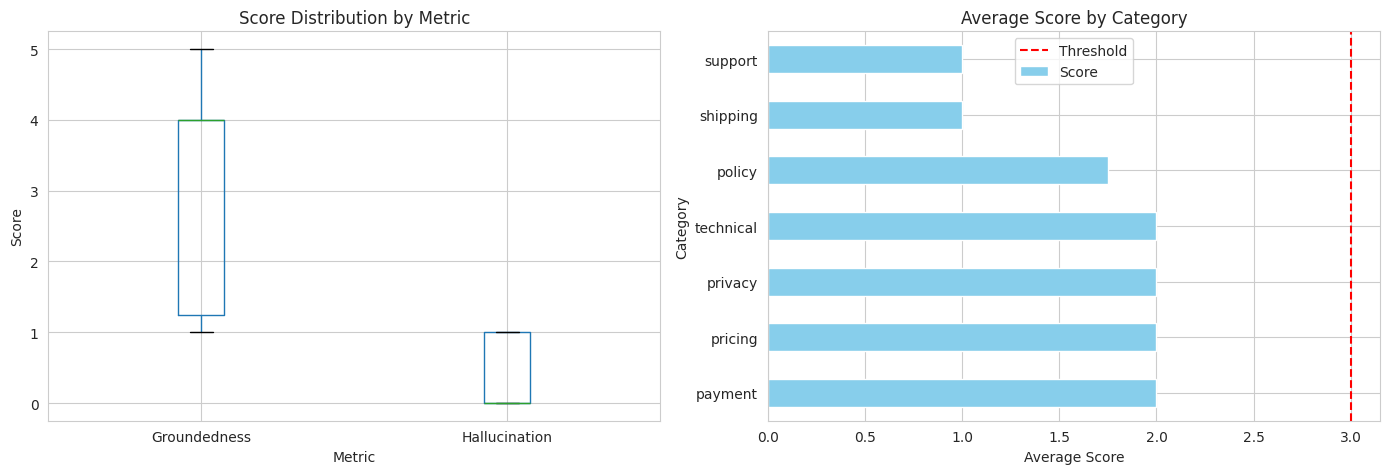


 Visualizations generated!


In [12]:
# Set style
sns.set_style('whitegrid')
plt.figure(figsize=(14, 5))

# Plot 1: Score distribution by metric
plt.subplot(1, 2, 1)
df_results.boxplot(column='Score', by='Metric', ax=plt.gca())
plt.title('Score Distribution by Metric')
plt.suptitle('')  # Remove default title
plt.xlabel('Metric')
plt.ylabel('Score')

# Plot 2: Average score by category
plt.subplot(1, 2, 2)
category_avg.plot(kind='barh', color='skyblue')
plt.title('Average Score by Category')
plt.xlabel('Average Score')
plt.ylabel('Category')
plt.axvline(x=3.0, color='red', linestyle='--', label='Threshold')
plt.legend()

plt.tight_layout()
plt.show()

print("\n Visualizations generated!")

## Deep Dive: Inspect a Specific Case

Let's look at the detailed evaluation of one of the flagged cases.

In [13]:
# Pick a case to inspect (preferably a flagged one)
if len(problematic) > 0:
    inspect_case = problematic.iloc[0]['Case ID']
    inspect_metric = problematic.iloc[0]['Metric']
else:
    # If no problematic cases, just pick the first one
    inspect_case = df_results.iloc[0]['Case ID']
    inspect_metric = df_results.iloc[0]['Metric']

# Get the evaluation result
result_key = f"{inspect_case}_{inspect_metric}"
eval_result = batch_result.results[result_key]

print(f"\n DETAILED INSPECTION: {inspect_case} - {inspect_metric}")
print("="*100)

# Show source and output
print(f"\n Source Text:")
print(test_dataset[inspect_case]['source_text'])
print(f"\n Model Output:")
print(test_dataset[inspect_case]['output'])

# Show results
print(f"\n Evaluation Results:")
print(f"   Final Score: {eval_result.final_score}")
print(f"   Valid: {eval_result.is_valid}")
print(f"   Confidence: {eval_result.confidence:.2%}")

# Show individual judge reasoning
print(f"\n Individual Judge Feedback:")
print("─"*100)
for i, score in enumerate(eval_result.manifest.individual_scores, 1):
    print(f"\nJudge {i}: {score.judge_id}")
    print(f"Score: {score.score}")
    print(f"Reasoning: {score.reasoning[:200]}...") if len(score.reasoning) > 200 else print(f"Reasoning: {score.reasoning}")
    print("─"*100)


 DETAILED INSPECTION: case_001_return_policy - Hallucination

 Source Text:
Our return policy allows returns within 30 days of purchase. 
        Items must be unused and in original packaging. Refunds are processed within 5-7 business days. 
        Shipping costs are non-refundable unless the item was defective.

 Model Output:
You can return items within 30 days if they're unused and in original packaging. 
        Refunds take 5-7 business days. Shipping costs aren't refunded unless the item was defective.

 Evaluation Results:
   Final Score: 0.0
   Valid: False
   Confidence: 100.00%

 Individual Judge Feedback:
────────────────────────────────────────────────────────────────────────────────────────────────────

Judge 1: Llama-3.1-8B
Score: 0.0
Reasoning: The model output is a direct copy of the source text, with no modifications or additions. The text is logically sound and factually accurate, and it is directly relevant to the user input, which is a ...
───────────────────────

## Export Results

Save the results for reporting and tracking over time.

In [14]:
# Export to CSV
output_file = 'rag_evaluation_results.csv'
df_results.to_csv(output_file, index=False)
print(f" Results exported to: {output_file}")

# Create summary report
summary_report = f"""
RAG EVALUATION SUMMARY REPORT
{'='*70}

Dataset: {len(test_dataset)} test cases
Metrics: {len(metrics)} ({', '.join([m.name for m in metrics])})
Judges: {len(jury.judges)}

OVERALL QUALITY: {overall_quality:.2f}/5

VALIDITY RATE: {validity_rate:.1f}%

FLAGGED FOR REVIEW: {len(problematic)} evaluations

TOP PERFORMING CATEGORY: {category_avg.index[0]} ({category_avg.iloc[0]:.2f})
NEEDS IMPROVEMENT: {category_avg.index[-1]} ({category_avg.iloc[-1]:.2f})

{'='*70}
"""

print(summary_report)

# Save summary
with open('evaluation_summary.txt', 'w') as f:
    f.write(summary_report)
print(" Summary saved to: evaluation_summary.txt")

 Results exported to: rag_evaluation_results.csv

RAG EVALUATION SUMMARY REPORT

Dataset: 10 test cases
Metrics: 2 (Groundedness, Hallucination)
Judges: 3

OVERALL QUALITY: 1.75/5

VALIDITY RATE: 50.0%

FLAGGED FOR REVIEW: 14 evaluations

TOP PERFORMING CATEGORY: payment (2.00)
NEEDS IMPROVEMENT: support (1.00)


 Summary saved to: evaluation_summary.txt


## Key Takeaways

### What We Learned:

1. **Batch Processing is Efficient**
   - Process entire datasets in one call
   - Parallel execution saves time
   - Consistent evaluation across all cases

2. **Multiple Metrics Provide Depth**
   - Groundedness + Hallucination catch different issues
   - Different metrics reveal different problems
   - Combined view gives complete picture

3. **DataFrames Enable Analysis**
   - Easy to filter, sort, and aggregate
   - Visual tables help spot patterns
   - Export for reporting and tracking

4. **Automated Flagging Saves Time**
   - Set thresholds for automatic review
   - Focus human attention where needed
   - Scale evaluation without linear effort

5. **Category Analysis Guides Improvement**
   - Identify weak areas in knowledge base
   - Prioritize document quality improvements
   - Track progress over time

---

## Production Best Practices

1. **Start Small, Scale Up**
   - Test with 10-20 cases first
   - Validate thresholds before full deployment
   - Adjust based on your specific domain

2. **Track Over Time**
   - Run batch evaluations on each release
   - Monitor for regression
   - Compare improvements

3. **Use Confidence Wisely**
   - Low confidence = human review needed
   - High confidence = can auto-approve
   - Track confidence trends

4. **Combine with Unit Tests**
   - Make batch evaluation part of CI/CD
   - Set quality gates for deployment
   - Prevent bad releases

5. **Iterate on Metrics**
   - Start with Groundedness + Hallucination
   - Add custom metrics for your domain
   - Weight metrics by importance

---

## Next Steps

- **04_Aggregation_Strategies.ipynb**: Try weighted voting and consensus thresholds
- **05_Custom_Metrics.ipynb**: Create domain-specific evaluation criteria
- **06_Agentic_Shield.ipynb**: Protect AI agents from compounding errors

---

**Happy Batch Processing!**